<a href="https://colab.research.google.com/github/byamasu-patrick/graph-neural-network-lab/blob/main/gnn_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simplifying Graph Neural Networks: Building a Graph Neural Network from Scratch

By **Byamasu Patrick Paul**
> *I am a Machine Learning Researcher specializing in Reinforcement Learning and Multi-Agent Systems, with research focused on graph representation learning and efficient communication in cooperative multi-agent environments. My work investigates how Graph Neural Networks (GNNs) can enable autonomous agents to exchange information efficiently while operating under partial observability.*

Graph Neural Networks have become one of the most influential deep learning architectures for learning from relational data. Unlike traditional neural networks, which assume that data is organized as vectors or grids, GNNs are specifically designed to learn from graphs, where entities are represented as nodes and their relationships as edges. This makes them particularly useful for applications such as recommendation systems, molecular modeling, knowledge graphs, social networks, and increasingly, Multi-Agent Reinforcement Learning.

The goal of this notebook is to develop an intuitive understanding of Graph Neural Networks by implementing one entirely from scratch using PyTorch. Instead of relying on specialized graph learning libraries, we will build the core components ourselves to understand exactly how information flows through a graph during message passing.

By the end of this notebook, you will understand:

* how graph data is represented,
* how message passing enables nodes to exchange information,
* how a Graph Neural Network layer is constructed from first principles,
* how to train a simple GNN for node classification, and
* why GNNs have become an effective architecture for learning over graph-structured data.

Once these foundations are clear, using libraries such as PyTorch Geometric or DGL becomes much easier because the underlying computations are no longer treated as a black box.

In [1]:
!pip install networkx[default]

In [36]:
# import networkx and matplotlib to plot the graphs
import networkx as nx
import matplotlib.pyplot as plt

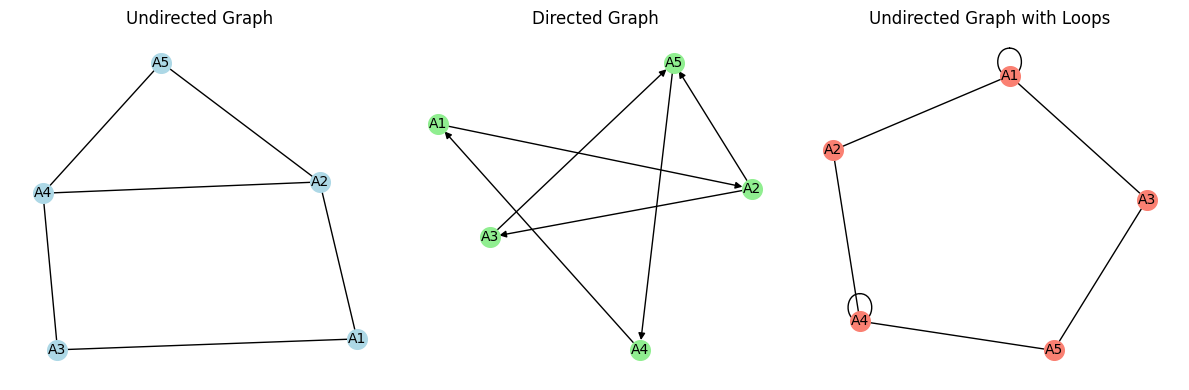

In [41]:
# Create an undirected graph with 4 nodes and we will connect the nodes by hand using
# add_edges_from() method
undirected_graph = nx.Graph()
undirected_graph.add_edges_from([
    ("A1","A2"),
    ("A1","A3"),
    ("A2","A4"),
    ("A3","A4"),
    ("A4","A5"),
    ("A2","A5")
])

# Here we create a directed graph
directed_graph = nx.DiGraph()
directed_graph.add_edges_from([
    ("A1","A2"),
    ("A2","A3"),
    ("A3","A5"),
    ("A5","A4"),
    ("A4","A1"),
    ("A2","A5")
])

# Create an undirected graph with loops
undirected_graph_loops = nx.Graph()
undirected_graph_loops.add_edges_from([
    ("A1","A2"),
    ("A1","A3"),
    ("A2","A4"),
    ("A3","A5"),
    ("A4","A5"),
    ("A1","A1"),
    ("A4","A4")
])

# Let's draw the graphs
plt.figure(figsize=(12, 4))

# Draw the undirected graph
plt.subplot(131)
nx.draw(undirected_graph, with_labels=True, node_color='lightblue', node_size=200, font_size=10)
plt.title("Undirected Graph")

# Draw the directed graph
plt.subplot(132)
nx.draw(directed_graph, with_labels=True, node_color='lightgreen', node_size=200, font_size=10, arrows=True)
plt.title("Directed Graph")

# Draw the undirected graph with loops
plt.subplot(133)
nx.draw(undirected_graph_loops, with_labels=True, node_color='salmon', node_size=200, font_size=10, arrows=True)
plt.title("Undirected Graph with Loops")

# Display the graphs
plt.tight_layout()
plt.show()

The examples above illustrate some of the most common graph structures encountered in practice. While these visualizations help us understand how graphs are organized, neural networks cannot operate directly on graphical representations. Like all machine learning models, they require numerical inputs.

To enable learning on graph-structured data, graphs must first be represented mathematically. Graph theory provides several ways to describe graphs, but for Graph Neural Networks, three representations are particularly important: the adjacency matrix, the degree matrix, and the feature matrix.

The **adjacency matrix** $\mathbf{A}$ captures the connectivity of the graph. It is a square matrix where both the rows and columns correspond to nodes. Each element indicates whether an edge exists between a pair of nodes. For an unweighted graph, an entry of 1 denotes a connection, while 0 indicates that no edge exists.

The **degree matrix** $\mathbf{D}$ summarizes the number of connections associated with each node. It is a diagonal matrix in which each diagonal element equals the degree of the corresponding node, while all off-diagonal elements are zero.

In addition to the graph structure, every node typically contains descriptive information known as **node features**. These features are stored in the **feature matrix** $\mathbf{X}$, where each row corresponds to a node and each column represents one of its attributes. For example, in a citation network, node features may indicate the presence or absence of specific words within a scientific paper, while in a social network they may represent user characteristics such as age, occupation, or interests.

Together, the adjacency matrix, degree matrix, and feature matrix provide a complete numerical representation of a graph that can be processed by Graph Neural Networks. In the next section, we will generate these matrices for the undirected graph constructed above and examine how they describe both the graph topology and the node attributes before implementing our first GNN layer.


In [42]:
import numpy as np
import pandas as pd
import networkx as nx

# ---------------------------------------------------------------------------------------
# 1. Adjacency Matrix
# ---------------------------------------------------------------------------------------

# Ensure consistent node ordering
nodes = sorted(undirected_graph.nodes())

# Generate adjacency matrix
A = nx.to_numpy_array(undirected_graph, nodelist=nodes, dtype=int)

# Convert to labeled DataFrame
A_df = pd.DataFrame(
    A,
    index=[f"Node {i}" for i in nodes],
    columns=[f"Node {i}" for i in nodes]
)

print("Adjacency Matrix (A):")
print(A_df)


# ---------------------------------------------------------------------------------------
# 2. Degree Matrix
# ---------------------------------------------------------------------------------------

# Compute node degrees
degrees = [undirected_graph.degree(node) for node in nodes]

# Create degree matrix
D = np.diag(degrees)

# Convert to labeled DataFrame
D_df = pd.DataFrame(
    D,
    index=[f"Node {i}" for i in nodes],
    columns=[f"Node {i}" for i in nodes]
)

print("\nDegree Matrix (D):")
print(D_df)

Adjacency Matrix (A):
         Node A1  Node A2  Node A3  Node A4  Node A5
Node A1        0        1        1        0        0
Node A2        1        0        0        1        1
Node A3        1        0        0        1        0
Node A4        0        1        1        0        1
Node A5        0        1        0        1        0

Degree Matrix (D):
         Node A1  Node A2  Node A3  Node A4  Node A5
Node A1        2        0        0        0        0
Node A2        0        3        0        0        0
Node A3        0        0        2        0        0
Node A4        0        0        0        3        0
Node A5        0        0        0        0        2


In [40]:
# Now let's also verify the Laplacian: L = D - A
L = D - A
print("\nGraph Laplacian (L = D - A):")
print(L)


Graph Laplacian (L = D - A):
[[ 2. -1. -1.  0.  0.]
 [-1.  3.  0. -1. -1.]
 [-1.  0.  2. -1.  0.]
 [ 0. -1. -1.  3. -1.]
 [ 0. -1.  0. -1.  2.]]


# GNN Implementation

Now how do we learn from graph data? The answer is with something called a Graph Neural Network (GNN).

A GNN is a special kind of neural network designed to work with graph data

In GNNs, we need operations that respect the graph's structure. Here is how this is done in GNNs:


1. **Symmetric Aggregation**: This involves using functions like sum, mean, or max to combine information from a node's neighbors. These functions don't care about the order of the nodes, making them perfect for keeping the graph structure.
2. **Parameter Sharing**: In GNNs, the same parameters are used across all nodes. This way, every node is treated equally, no matter where it is in the graph.
3. **Readout Function**: If the goal is to understand the whole graph (like classifying the graph into categories), we use a special function that treats the entire graph as a single entity. This function doesn't change based on the order of the nodes.

By sticking to these principles, a GNN can effectively learn from graph data, regardless of how the nodes in the graph are ordered.



We can use the adjacency matrix to show the connections in the graph. In addition, we also have the feature matrix that describes the characteristics or the features of each node.

In a simple graph layer, we might use a formula like $\mathbf{h} = \mathbf{W}\mathbf{A}\mathbf{X}$, which combines node features $\mathbf{X}$ with graph connectivity $\mathbf{A}$, where $\mathbf{W}$ are the weights of the layer. *Multiplying by the adjacency matrix ensures that we include the features of neighboring nodes as it encodes the graph connectivity.*

But there's a catch: this method doesn't include the features of the central node itself, where the central node in this context refers to a specific node that is the focus of analysis or computation at a given moment. To fix this, we add what's called self loops to the adjacency matrix. This means we adjust the matrix to include connections from nodes to themselves.

We do this by adding the identity matrix $\mathbf{I}$ to the adjacency matrix $\mathbf{A}$, creating a new adjacency matrix $\tilde{\mathbf{A}}$. Formally,

\begin{equation}
\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}.
\end{equation}

The graph convolution then becomes

\begin{equation}
\mathbf{H} = \mathbf{W}\tilde{\mathbf{A}}\mathbf{X},
\end{equation}

where $\mathbf{W}$ denotes the learnable weight matrix (i.e., the trainable parameters of the GNN layer), $\mathbf{X}$ is the input feature matrix, and $\mathbf{H}$ is the resulting node representation. By introducing self-loops through $\mathbf{I}$, each node aggregates information from both its own features and those of its neighboring nodes, resulting in richer and more informative representations.

Now, let's proceed to implement our GNN layer and put it to the test on a real-world graph dataset. We'll compare our GNN with a simple Multi-Layer Perceptron (MLP) to see how well it does. We'll use PyTorch to build our GNN.

For the data we'll use, there's a dataset called the Cora dataset. The Cora dataset comprises 2708 scientific publications, each classified into one of seven distinct classes. It features a citation network with 5429 links. Every publication in the dataset is characterized by a binary word vector, which represents the absence (0) or presence (1) of certain words from a dictionary of 1433 unique terms. Our goal is to classify each node (publication) into one of these seven classes.

While the Cora dataset can be accessed directly from its official website, we'll use PyTorch Geometric (PyG) to download it. PyG is a library built upon PyTorch to easily write and train GNNs.

In [19]:
# For GPU (CUDA 12.x)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# OR for CPU-only version
# pip install torch torchvision torchaudio

Looking in indexes: https://download.pytorch.org/whl/cu121


In [20]:
# Install core PyG packages and its dependencies
!pip install torch-geometric

# (Optional) Install additional operators if needed
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.4.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 90.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 78.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 19.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 989.6/989.6 kB 7.3 MB/s eta 0:00:00


This code downloads the Cora citation network dataset using the Planetoid class from **PyG**, stores it in the current directory, and accesses its single graph. It then prints key information about the dataset - including the number of graphs, nodes (**papers**), features (**attributes per paper**), and classes (**research topics**) - giving you a quick overview of the dataset’s structure

In [22]:
# Import the Planetoid class from PyG
from torch_geometric.datasets import Planetoid

# Then download the Cora dataset using this class. We will donwload it in the current directory (.)
dataset = Planetoid(root=".", name="cora")

# Cora only has one graph, can be accessed as follows
cora = dataset[0]

print(f'Dataset: {dataset.name}')
print('----------------------------------------------------------')
print(f'Number of graphs: {len(dataset)}') # how many graphs in this dataset
print(f'Number of nodes: {cora.x.shape[0]}') # here, x, is the feature matrix
print(f'Number of features: {dataset.num_features}') # how many features, how many columns are in x
print(f'Number of classes: {dataset.num_classes}') # how many classes

Dataset: cora
----------------------------------------------------------
Number of graphs: 1
Number of nodes: 2708
Number of features: 1433
Number of classes: 7


In [23]:
# PyTorch imports
import torch
import torch.nn.functional as F

# A simple feed forward network for multiclass classification
class MLP(torch.nn.Module):
    def __init__(self, in_features, hidden_features, out_features, activation=torch.nn.ReLU):
        super().__init__()
        self.layer1 = torch.nn.Linear(in_features, hidden_features)
        self.layer2 = torch.nn.Linear(hidden_features, out_features)

        self.activation = activation()

    def forward(self, x):
        h = self.layer1(x)
        h = self.activation(h)
        h = self.layer2(h)
        out = F.log_softmax(h, dim=1)

        return out

In [24]:
#  we split the graph into train (80%) and test (20%) datasets using the famous scikit-learn package
from sklearn.model_selection import train_test_split

# Extract the node features and the labels
X, y = cora.x.numpy(), cora.y.numpy()

# Split the data into train and test sets (80%, 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

# Convert to PyTorch tensors
train_data = {"X": torch.tensor(X_train, dtype=torch.float32), "y":torch.tensor(y_train, dtype=torch.long)}
test_data = {"X": torch.tensor(X_test, dtype=torch.float32), "y":torch.tensor(y_test, dtype=torch.long)}

In [25]:
import torch
import numpy as np
from tqdm import trange

# Training Function
def fit(model, data, criterion, config):
    """
    Train a PyTorch model on the given dataset.

    Args:
        model: The neural network model (PyTorch module)
        data:  Dictionary containing input features 'X' and labels 'y'
        criterion: Loss function
        config: Object or dict containing hyperparameters like:
                - device (e.g. 'cuda' or 'cpu')
                - lr (learning rate)
                - max_epochs (number of training epochs)

    Returns:
        Dictionary containing lists of training loss, accuracy, and epoch indices.
    """

    # Move model to the specified device (CPU or GPU)
    device = config.device
    model = model.to(device)

    # Define optimizer (AdamW is a good default choice)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=0.0)

    # Prepare data and move tensors to the device
    X = None
    if isinstance(data["X"], torch.Tensor):
        X = data["X"].to(device)
    elif isinstance(data["X"], dict):
        # Handle case where X is a dictionary of tensors
        for key, value in data["X"].items():
            if isinstance(value, torch.Tensor):
                data["X"][key] = value.to(device)
        X = data["X"]

    y = data["y"].to(device)

    # Lists to store loss and accuracy values per epoch
    train_loss, train_acc = [], []

    # Training loop
    pbar = trange(config.max_epochs, unit=" epochs")
    for epoch in pbar:
        pbar.set_description(f"Epoch {epoch + 1}")

        # Reset gradients before each iteration
        optimizer.zero_grad()

        # Forward pass: compute predictions
        y_pred = model(X)

        # Compute the loss between prediction and target
        loss = criterion(y_pred, y)

        # Backpropagation: compute gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        # Compute accuracy for this epoch
        _, predicted = torch.max(y_pred.data, 1)  # Get class with highest score
        total = y.size(0)
        correct = (predicted == y).sum().item()
        accuracy = 100 * correct / total

        # Store metrics
        train_loss.append(loss.item())
        train_acc.append(accuracy)

        # Display metrics in progress bar
        pbar.set_postfix(loss=loss.item(), accuracy=f"{accuracy:.2f}%")

    # Return results for plotting or analysis
    return {
        "train_loss": train_loss,
        "train_acc": train_acc,
        "iterations": np.arange(1, config.max_epochs + 1)
    }

In [26]:
# Testing Function
def test(model, data):
    """
    Evaluate a trained model on test data.

    Args:
        model: Trained PyTorch model
        data:  Dictionary with 'X' and 'y' tensors for testing
    """
    model.eval()  # Set model to evaluation mode (no dropout, etc.)
    model = model.cpu()

    # Move data to CPU
    X = None
    if isinstance(data["X"], torch.Tensor):
        X = data["X"].cpu()
    elif isinstance(data["X"], dict):
        for key, value in data["X"].items():
            if isinstance(value, torch.Tensor):
                data["X"][key] = value.cpu()
        X = data["X"]

    y = data["y"].cpu()

    # Forward pass (no gradient computation needed)
    with torch.no_grad():
        yhat = model(X)

    # Compute accuracy
    _, predicted = torch.max(yhat.data, 1)
    total = y.size(0)
    correct = (predicted == y).sum().item()
    test_acc = 100 * correct / total

    print(f"Testing accuracy: {test_acc:.2f}%")

In [28]:
# We define a simple configuration class to set the training parameters and then train the MLP model
class Config:
    pass

config = Config()
config.device     = "cuda" if torch.cuda.is_available() else "cpu"
config.max_epochs = 100
config.lr         = 1e-3

mlp = MLP(in_features=X.shape[1], hidden_features=32, out_features=dataset.num_classes)

# Train the MLP
history = fit(model=mlp, data=train_data, criterion=torch.nn.CrossEntropyLoss(), config=config)

Epoch 100: 100%|██████████| 100/100 [00:01<00:00, 56.80 epochs/s, accuracy=93.35%, loss=0.549]


In [29]:
# Test the MLP on the hold-out dataset
test(model=mlp, data=test_data)

Testing accuracy: 73.25%


Now comes the thrilling part: training our custom-built **GNN**. The first thing we need is the **adjacency matrix**. In the Cora dataset, this information is stored as an **edge index**, which is a way to store graph edges. The **edge index** is a 2-row matrix, where each column represents an edge. We'll convert this into a dense matrix using **PyG**. Once we have our adjacency matrix ready, we'll be all set to start building our own GNN:

In [30]:
from torch_geometric.utils import to_dense_adj

# The adjacency matrix as a dense (square) matrix
A = to_dense_adj(cora.edge_index)[0]

# Now we should add the self-loops (the Identity Matrix)
I = torch.eye(len(A))
A += I
print(A, A.shape)

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 1.],
        [0., 0., 0.,  ..., 0., 1., 1.]]) torch.Size([2708, 2708])


We now have all the ingredients required to implement a Graph Neural Network layer. The feature matrix stores the attributes of every node, while the adjacency matrix defines how information flows between neighboring nodes. During the forward pass, multiplying the feature matrix by the adjacency matrix aggregates information from neighboring nodes. The resulting representations are then transformed by a learnable weight matrix before passing through a nonlinear activation function. This entire process is commonly referred to as **message passing**.

In [32]:
# A simple Graph Neural Network (GNN) built from scratch for multiclass node classification
class GNN(torch.nn.Module):
    def __init__(self, in_features, hidden_features, out_features, activation=torch.nn.ReLU):
        super().__init__()
        # Linear layer to transform input node features (acts like weight matrix W in h = WAX)
        self.W = torch.nn.Linear(in_features, hidden_features)

        # Classifier layer to map hidden representations to class scores
        self.classifier = torch.nn.Linear(hidden_features, out_features)

        # Non-linear activation function (default: ReLU)
        self.activation = activation()

    def forward(self, inputs):
        # Unpack node features (X) and adjacency matrix (A)
        X, A = inputs["node_features"], inputs["adjacency_matrix"]

        # Message passing: aggregate neighbor features using A, then apply learnable weights
        h = self.W(A @ X)

        # Apply non-linearity
        h = self.activation(h)

        # Map to class logits
        h = self.classifier(h)

        # Compute log probabilities for classification
        out = F.log_softmax(h, dim=1)

        return out

Please note, that this line of code self.W(A@X) is exactly the equation
$\mathbf{h} = \mathbf{W}\tilde{\mathbf{A}}\mathbf{X}$, we constructed above .

In [33]:
# Inputs to our GNN model
gnn_inputs = {"X": {"node_features":cora.x, "adjacency_matrix":A}, "y":cora.y}

gnn = GNN(in_features=cora.x.shape[1], hidden_features=32, out_features=7)

# Train the GNN
history = fit(model=gnn, data=gnn_inputs, criterion=torch.nn.CrossEntropyLoss(), config=config)

Epoch 100: 100%|██████████| 100/100 [00:40<00:00,  2.44 epochs/s, accuracy=95.79%, loss=0.216]


In [34]:
test(model=gnn, data=gnn_inputs)

Testing accuracy: 95.79%


Congratulations! You've successfully implemented your very first GNN from scratch. This is a remarkable achievement that demonstrates both your curiosity and technical skill in understanding the foundations of graph-based deep learning.

Your journey so far has built a solid foundation for exploring more advanced graph neural network architectures. One of the most influential next steps is the **Graph Convolutional Network (GCN)** introduced by *Thomas Kipf and Max Welling*, which established a powerful framework for learning node representations by leveraging graph structure and neighborhood aggregation.

From there, several important GNN architectures have expanded the capabilities of graph-based learning. The **Graph Attention Network (GAT)**, introduced by *Petar Veličković* and collaborators, extends graph convolution by using attention mechanisms to learn the importance of different neighboring nodes dynamically. **GraphSAGE**, introduced by William Hamilton, Rex Ying, and Jure Leskovec, focuses on scalable representation learning by sampling and aggregating information from local neighborhoods, making it suitable for large-scale graphs.

Other influential architectures and extensions include **Graph Isomorphism Networks (GIN)**, which improve the expressive power of GNNs by incorporating ideas from graph isomorphism tests, and **Temporal Graph Neural Networks (TGNNs)**, which model evolving relationships and dynamic graph structures over time.

Exploring these architectures will provide a deeper understanding of how graph neural networks learn representations, aggregate information, and solve complex problems across domains such as social networks, recommendation systems, molecular modeling, and multi-agent systems.
